# Credit Card Default Prediction

**Goal.** Predict whether a credit card client will default on their payment next month, using demographics, credit limit, six months of repayment status, bill amounts and payment amounts.

**Type.** Binary classification (default = 1).

**Why it matters.** Missing a defaulter (false negative) costs the lender the unpaid balance, while flagging a good client (false positive) costs a lost or restricted customer. We therefore focus on recall, PR-AUC and the decision threshold, not accuracy.

**Approach.** Train several diverse base models (Logistic Regression, KNN, Decision Tree), then combine them with a Voting Classifier (hard vs soft voting) and compare it against each individual model.

In [2]:
import shutil
from pathlib import Path

import kagglehub
import pandas as pd

path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
print("Downloaded to:", path)

csv_file = next(Path(path).rglob("*.csv"))
raw = Path("../data/raw")
raw.mkdir(parents=True, exist_ok=True)
shutil.copy(csv_file, raw / csv_file.name)

df = pd.read_csv(raw / csv_file.name)
print(csv_file.name, df.shape)
df.head()

100%|██████████| 0.98M/0.98M [00:14<00:00, 69.1kB/s]

Extracting files...
Downloaded to: C:\Users\Abdel\.cache\kagglehub\datasets\uciml\default-of-credit-card-clients-dataset\versions\1
UCI_Credit_Card.csv (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
import pandas as pd
df = pd.read_csv("../data/raw/UCI_Credit_Card.csv")
print(df.shape)

(30000, 25)


In [4]:
df.info()
print("Duplicated rows (ignoring ID):", df.drop(columns="ID").duplicated().sum())
print(df["default.payment.next.month"].value_counts(normalize=True).round(3))

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [5]:
for c in ["SEX", "EDUCATION", "MARRIAGE", "PAY_0"]:
    print(df[c].value_counts().sort_index(), "\n")

SEX
1    11888
2    18112
Name: count, dtype: int64 

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64 

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64 

PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64 



In [6]:
print("Duplicated rows (ignoring ID):", df.drop(columns="ID").duplicated().sum())
print("Missing values:", df.isnull().sum().sum())
print(df["PAY_0"].value_counts().sort_index().to_string())

Duplicated rows (ignoring ID): 35
Missing values: 0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19


In [7]:
df = df.drop(columns="ID")
df = df.rename(columns={"PAY_0": "PAY_1", "default.payment.next.month": "default"})

df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Dropped duplicates:", before - len(df), "| shape:", df.shape)
print(df["EDUCATION"].value_counts().sort_index(), "\n")
print(df["MARRIAGE"].value_counts().sort_index())

Dropped duplicates: 35 | shape: (29965, 24)
EDUCATION
1    10563
2    14019
3     4915
4      468
Name: count, dtype: int64 

MARRIAGE
1    13643
2    15945
3      377
Name: count, dtype: int64


In [8]:
for c in ["SEX", "EDUCATION", "MARRIAGE", "PAY_1"]:
    t = df.groupby(c)["default"].agg(n="size", default_rate="mean")
    t["default_rate"] = (t["default_rate"] * 100).round(1)
    print(c); print(t, "\n")

SEX
         n  default_rate
SEX                     
1    11874          24.2
2    18091          20.8 

EDUCATION
               n  default_rate
EDUCATION                     
1          10563          19.2
2          14019          23.7
3           4915          25.2
4            468           7.1 

MARRIAGE
              n  default_rate
MARRIAGE                     
1         13643          23.5
2         15945          20.9
3           377          23.6 

PAY_1
           n  default_rate
PAY_1                     
-2      2750          13.2
-1      5682          16.8
 0     14737          12.8
 1      3667          34.0
 2      2666          69.1
 3       322          75.8
 4        76          68.4
 5        26          50.0
 6        11          54.5
 7         9          77.8
 8        19          57.9 



In [9]:
bill = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_amt = [f"PAY_AMT{i}" for i in range(1, 7)]

print(df[["LIMIT_BAL", "AGE"] + bill + pay_amt].describe().T[["min", "50%", "max"]])
print("\nRows with any negative bill:", (df[bill] < 0).any(axis=1).sum())

                min       50%        max
LIMIT_BAL   10000.0  140000.0  1000000.0
AGE            21.0      34.0       79.0
BILL_AMT1 -165580.0   22438.0   964511.0
BILL_AMT2  -69777.0   21295.0   983931.0
BILL_AMT3 -157264.0   20135.0  1664089.0
BILL_AMT4 -170000.0   19081.0   891586.0
BILL_AMT5  -81334.0   18130.0   927171.0
BILL_AMT6 -339603.0   17124.0   961664.0
PAY_AMT1        0.0    2102.0   873552.0
PAY_AMT2        0.0    2010.0  1684259.0
PAY_AMT3        0.0    1804.0   896040.0
PAY_AMT4        0.0    1500.0   621000.0
PAY_AMT5        0.0    1500.0   426529.0
PAY_AMT6        0.0    1500.0   528666.0

Rows with any negative bill: 1930


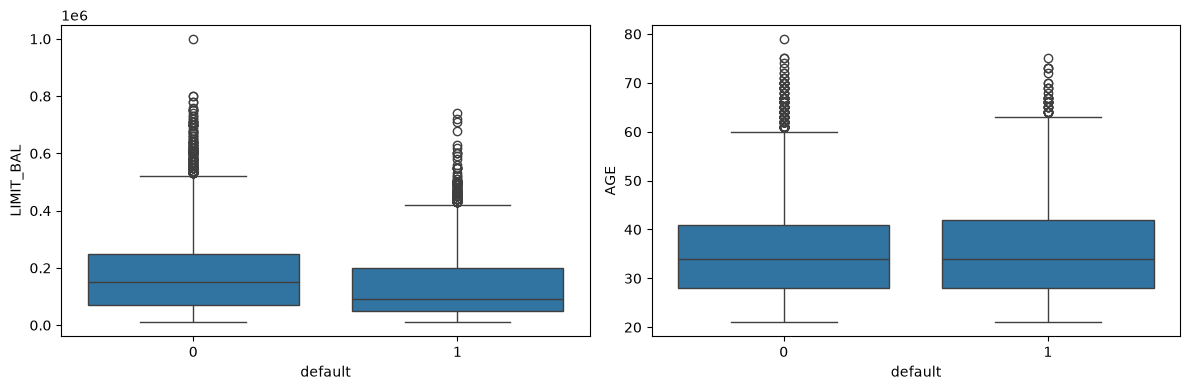

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="default", y="LIMIT_BAL", ax=ax[0])
sns.boxplot(data=df, x="default", y="AGE", ax=ax[1])
plt.tight_layout(); plt.show()

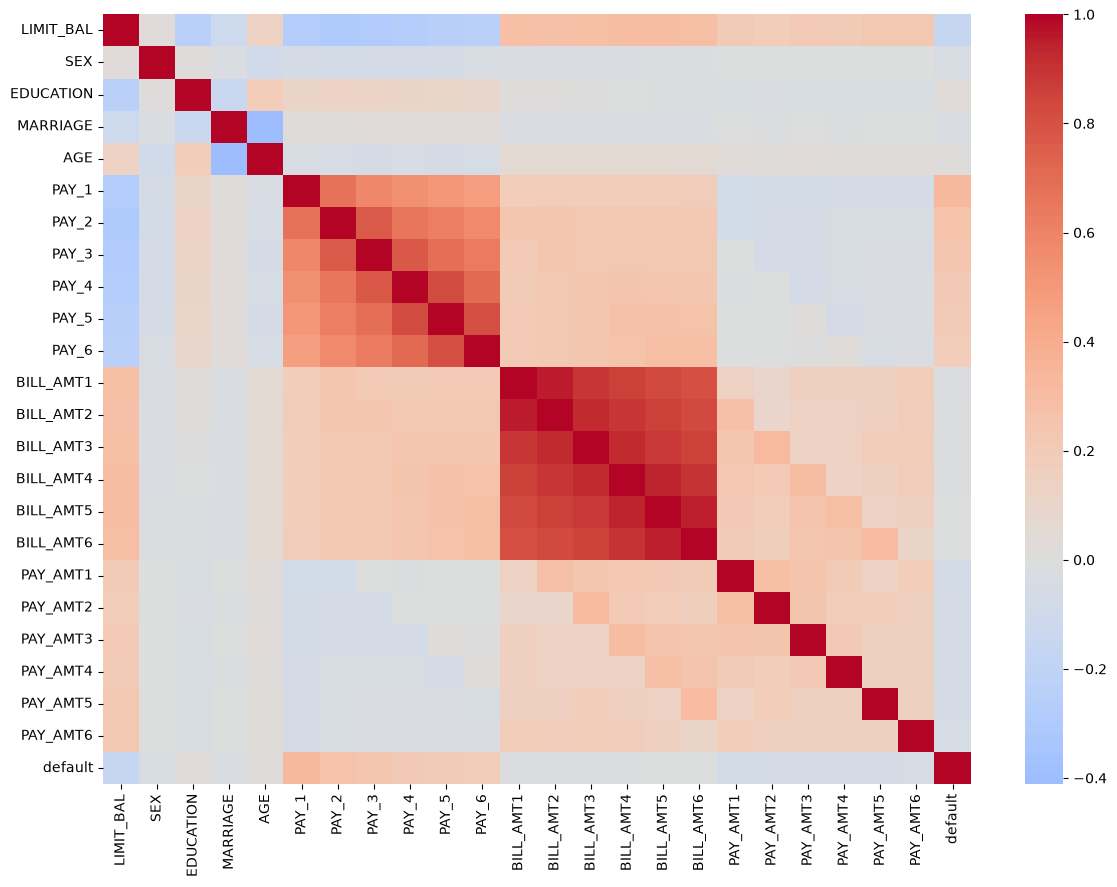

PAY_1        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
LIMIT_BAL   -0.154
PAY_AMT1    -0.073
PAY_AMT2    -0.059
PAY_AMT4    -0.057
PAY_AMT3    -0.056
PAY_AMT5    -0.055
PAY_AMT6    -0.053
SEX         -0.040
EDUCATION    0.034
MARRIAGE    -0.027
BILL_AMT1   -0.020
BILL_AMT2   -0.014
BILL_AMT3   -0.014
AGE          0.014
BILL_AMT4   -0.010
BILL_AMT5   -0.007
BILL_AMT6   -0.005
Name: default, dtype: float64

BILL_AMT correlations:
            BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6
BILL_AMT1       1.00       0.95       0.89       0.86       0.83       0.80
BILL_AMT2       0.95       1.00       0.93       0.89       0.86       0.83
BILL_AMT3       0.89       0.93       1.00       0.92       0.88       0.85
BILL_AMT4       0.86       0.89       0.92       1.00       0.94       0.90
BILL_AMT5       0.83       0.86       0.88       0.94       1.00       0.95
BILL_AMT6       0.80       0.83       0.85       0.9

In [11]:
corr = df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()

print(corr["default"].drop("default").sort_values(key=abs, ascending=False).round(3))
print("\nBILL_AMT correlations:\n", df[bill].corr().round(2))

In [12]:
t = df.groupby("PAY_1")["default"].agg(n="size", default_rate="mean")
t["default_rate"] = (t["default_rate"] * 100).round(1)
print(t.to_string())

           n  default_rate
PAY_1                     
-2      2750          13.2
-1      5682          16.8
 0     14737          12.8
 1      3667          34.0
 2      2666          69.1
 3       322          75.8
 4        76          68.4
 5        26          50.0
 6        11          54.5
 7         9          77.8
 8        19          57.9


In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="default")
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Default rate  train:", round(y_train.mean(), 4), "| test:", round(y_test.mean(), 4))

Train: (23972, 23) | Test: (5993, 23)
Default rate  train: 0.2213 | test: 0.2213


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)
print(X_train_p.shape, X_test_p.shape)
print(preprocessor.get_feature_names_out())

(23972, 29) (5993, 29)
['num__LIMIT_BAL' 'num__AGE' 'num__PAY_1' 'num__PAY_2' 'num__PAY_3'
 'num__PAY_4' 'num__PAY_5' 'num__PAY_6' 'num__BILL_AMT1' 'num__BILL_AMT2'
 'num__BILL_AMT3' 'num__BILL_AMT4' 'num__BILL_AMT5' 'num__BILL_AMT6'
 'num__PAY_AMT1' 'num__PAY_AMT2' 'num__PAY_AMT3' 'num__PAY_AMT4'
 'num__PAY_AMT5' 'num__PAY_AMT6' 'cat__SEX_1' 'cat__SEX_2'
 'cat__EDUCATION_1' 'cat__EDUCATION_2' 'cat__EDUCATION_3'
 'cat__EDUCATION_4' 'cat__MARRIAGE_1' 'cat__MARRIAGE_2' 'cat__MARRIAGE_3']


In [15]:
import warnings
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

def make(clf):
    return Pipeline([("prep", clone(preprocessor)), ("clf", clf)])

models = {
    "Dummy": make(DummyClassifier(strategy="prior")),
    "Logistic Regression": make(LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42)),
    "KNN (k=15)": make(KNeighborsClassifier(n_neighbors=15, n_jobs=-1)),
    "Decision Tree": make(DecisionTreeClassifier(
        class_weight="balanced", max_depth=5, min_samples_leaf=20, random_state=42)),
}

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"recall": "recall", "precision": "precision", "f1": "f1",
           "roc_auc": "roc_auc", "pr_auc": "average_precision"}

rows = {}
for name, m in models.items():
    res = cross_validate(m, X_train, y_train, cv=cv, scoring=scoring)
    rows[name] = {k: f"{res[f'test_{k}'].mean():.3f} ± {res[f'test_{k}'].std():.3f}"
                  for k in scoring}

pd.DataFrame(rows).T

,recall,precision,f1,roc_auc,pr_auc
Dummy,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.500 ± 0.000,0.221 ± 0.000
Logistic Regression,0.650 ± 0.022,0.378 ± 0.008,0.478 ± 0.011,0.726 ± 0.011,0.501 ± 0.015
KNN (k=15),0.337 ± 0.011,0.627 ± 0.021,0.438 ± 0.013,0.740 ± 0.005,0.476 ± 0.008
Decision Tree,0.626 ± 0.049,0.445 ± 0.034,0.517 ± 0.008,0.761 ± 0.005,0.518 ± 0.008


In [17]:
from sklearn.ensemble import VotingClassifier

def voting_pipe(voting, weights=None):
    base = [
        ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=15)),
        ("dt", DecisionTreeClassifier(class_weight="balanced", max_depth=5,
                                       min_samples_leaf=20, random_state=42)),
    ]
    return Pipeline([
        ("prep", clone(preprocessor)),
        ("clf", VotingClassifier(base, voting=voting, weights=weights)),
    ])

In [18]:
label_scoring = {k: scoring[k] for k in ["recall", "precision", "f1"]}

vote_rows = {}
for name, m, sc in [("Voting (hard)", voting_pipe("hard"), label_scoring),
                    ("Voting (soft)", voting_pipe("soft"), scoring)]:
    res = cross_validate(m, X_train, y_train, cv=cv, scoring=sc)
    vote_rows[name] = {k: f"{res[f'test_{k}'].mean():.3f} ± {res[f'test_{k}'].std():.3f}"
                       for k in sc}

pd.concat([pd.DataFrame(rows).T, pd.DataFrame(vote_rows).T]).fillna("-")

,recall,precision,f1,roc_auc,pr_auc
Dummy,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.500 ± 0.000,0.221 ± 0.000
Logistic Regression,0.650 ± 0.022,0.378 ± 0.008,0.478 ± 0.011,0.726 ± 0.011,0.501 ± 0.015
KNN (k=15),0.337 ± 0.011,0.627 ± 0.021,0.438 ± 0.013,0.740 ± 0.005,0.476 ± 0.008
Decision Tree,0.626 ± 0.049,0.445 ± 0.034,0.517 ± 0.008,0.761 ± 0.005,0.518 ± 0.008
Voting (hard),0.546 ± 0.017,0.513 ± 0.019,0.529 ± 0.010,-,-
Voting (soft),0.504 ± 0.009,0.562 ± 0.012,0.532 ± 0.008,0.766 ± 0.007,0.535 ± 0.011


In [19]:
import numpy as np

sc = {"roc_auc": "roc_auc", "pr_auc": "average_precision"}
res_tree = cross_validate(models["Decision Tree"], X_train, y_train, cv=cv, scoring=sc)
res_soft = cross_validate(voting_pipe("soft"), X_train, y_train, cv=cv, scoring=sc)

for m in sc:
    d = res_soft[f"test_{m}"] - res_tree[f"test_{m}"]
    print(f"{m}: diff per fold = {np.round(d, 4)} | mean = {d.mean():.4f} | Soft wins {(d > 0).sum()}/5 folds")

roc_auc: diff per fold = [0.0021 0.0077 0.0049 0.0018 0.0097] | mean = 0.0052 | Soft wins 5/5 folds
pr_auc: diff per fold = [0.0139 0.0183 0.0196 0.0128 0.0249] | mean = 0.0179 | Soft wins 5/5 folds


In [20]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

def best_threshold(y_true, proba, beta=1):
    p, r, t = precision_recall_curve(y_true, proba)
    f = (1 + beta**2) * p * r / (beta**2 * p + r + 1e-12)
    i = np.argmax(f[:-1])
    return t[i], p[i], r[i], f[i]

oof = {}
for name, m in [("Decision Tree", models["Decision Tree"]),
                ("Voting (soft)", voting_pipe("soft"))]:
    oof[name] = cross_val_predict(m, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    for beta in (1, 2):
        t, p, r, f = best_threshold(y_train, oof[name], beta)
        print(f"{name:14s} F{beta}: thr={t:.3f} | precision={p:.3f} | recall={r:.3f} | F{beta}={f:.3f}")

Decision Tree  F1: thr=0.573 | precision=0.523 | recall=0.541 | F1=0.532
Decision Tree  F2: thr=0.242 | precision=0.295 | recall=0.869 | F2=0.626
Voting (soft)  F1: thr=0.462 | precision=0.531 | recall=0.541 | F1=0.536
Voting (soft)  F2: thr=0.284 | precision=0.312 | recall=0.838 | F2=0.627


In [22]:
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, recall_score, precision_score, f1_score)

thr_f1_soft, *_ = best_threshold(y_train, oof["Voting (soft)"], beta=1)
thr_f2_soft, *_ = best_threshold(y_train, oof["Voting (soft)"], beta=2)
thr_f1_tree, *_ = best_threshold(y_train, oof["Decision Tree"], beta=1)

soft = voting_pipe("soft").fit(X_train, y_train)
tree = clone(models["Decision Tree"]).fit(X_train, y_train)
proba_soft = soft.predict_proba(X_test)[:, 1]
proba_tree = tree.predict_proba(X_test)[:, 1]

def report(name, proba, thr):
    pred = (proba >= thr).astype(int)
    print(f"===== {name} (threshold={thr:.3f}) =====")
    print(classification_report(y_test, pred, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred), "\n")

report("Voting (soft), F1 threshold", proba_soft, thr_f1_soft)
report("Voting (soft), F2 threshold", proba_soft, thr_f2_soft)
report("Decision Tree, F1 threshold", proba_tree, thr_f1_tree)

for n, p in [("Voting (soft)", proba_soft), ("Decision Tree", proba_tree)]:
    print(f"{n}: ROC-AUC={roc_auc_score(y_test, p):.3f} | PR-AUC={average_precision_score(y_test, p):.3f}")

===== Voting (soft), F1 threshold (threshold=0.462) =====
              precision    recall  f1-score   support

           0      0.865     0.869     0.867      4667
           1      0.531     0.522     0.526      1326

    accuracy                          0.792      5993
   macro avg      0.698     0.695     0.697      5993
weighted avg      0.791     0.792     0.791      5993

Confusion matrix:
 [[4055  612]
 [ 634  692]] 

===== Voting (soft), F2 threshold (threshold=0.284) =====
              precision    recall  f1-score   support

           0      0.903     0.472     0.620      4667
           1      0.306     0.821     0.446      1326

    accuracy                          0.549      5993
   macro avg      0.604     0.646     0.533      5993
weighted avg      0.771     0.549     0.582      5993

Confusion matrix:
 [[2204 2463]
 [ 238 1088]] 

===== Decision Tree, F1 threshold (threshold=0.573) =====
              precision    recall  f1-score   support

           0      0.8

In [23]:
rng = np.random.RandomState(42)
yt = y_test.values
pred_soft = (proba_soft >= thr_f1_soft).astype(int)

rows, diffs = [], []
for _ in range(1000):
    i = rng.randint(0, len(yt), len(yt))
    rows.append([recall_score(yt[i], pred_soft[i]), precision_score(yt[i], pred_soft[i]),
                 f1_score(yt[i], pred_soft[i]),
                 roc_auc_score(yt[i], proba_soft[i]), average_precision_score(yt[i], proba_soft[i])])
    diffs.append([roc_auc_score(yt[i], proba_soft[i]) - roc_auc_score(yt[i], proba_tree[i]),
                  average_precision_score(yt[i], proba_soft[i]) - average_precision_score(yt[i], proba_tree[i])])

ci = np.percentile(rows, [2.5, 97.5], axis=0)
for n, lo, hi in zip(["Recall", "Precision", "F1", "ROC-AUC", "PR-AUC"], ci[0], ci[1]):
    print(f"{n:9s}: 95% CI [{lo:.3f}, {hi:.3f}]")

d = np.percentile(diffs, [2.5, 97.5], axis=0)
print(f"\nSoft - Tree ROC-AUC diff: 95% CI [{d[0][0]:.4f}, {d[1][0]:.4f}]")
print(f"Soft - Tree PR-AUC  diff: 95% CI [{d[0][1]:.4f}, {d[1][1]:.4f}]")

Recall   : 95% CI [0.495, 0.548]
Precision: 95% CI [0.505, 0.559]
F1       : 95% CI [0.504, 0.548]
ROC-AUC  : 95% CI [0.739, 0.771]
PR-AUC   : 95% CI [0.502, 0.561]

Soft - Tree ROC-AUC diff: 95% CI [0.0014, 0.0166]
Soft - Tree PR-AUC  diff: 95% CI [0.0139, 0.0382]


In [24]:
test_df = X_test.copy()
test_df["y_true"] = y_test.values
test_df["proba"] = proba_soft
test_df["y_pred"] = (proba_soft >= thr_f1_soft).astype(int)
test_df["tp"] = ((test_df.y_true == 1) & (test_df.y_pred == 1)).astype(int)

test_df["outcome"] = np.select(
    [(test_df.y_true == 1) & (test_df.y_pred == 1),
     (test_df.y_true == 1) & (test_df.y_pred == 0),
     (test_df.y_true == 0) & (test_df.y_pred == 1)],
    ["TP", "FN", "FP"], default="TN")

print(test_df["outcome"].value_counts(), "\n")
cols = ["PAY_1", "PAY_2", "LIMIT_BAL", "BILL_AMT1", "PAY_AMT1", "AGE", "proba"]
print(test_df.groupby("outcome")[cols].mean().round(2))

outcome
TN    4055
TP     692
FN     634
FP     612
Name: count, dtype: int64 

         PAY_1  PAY_2  LIMIT_BAL  BILL_AMT1  PAY_AMT1    AGE  proba
outcome                                                            
FN       -0.44  -0.48  161482.65   53277.88   5309.19  36.07   0.31
FP        1.16   0.82  113660.13   37509.96   1866.97  34.60   0.63
TN       -0.44  -0.49  187960.54   53678.49   7005.88  35.54   0.28
TP        1.66   1.30  106098.27   48030.04   2160.17  36.35   0.71


In [25]:
test_df["pay1_band"] = pd.cut(test_df["PAY_1"], [-3, 0, 1, 2, 8],
                              labels=["<=0 (no delay)", "1", "2", "3+"])

def band_table(col):
    g = test_df.groupby(col, observed=True)
    out = g.agg(n=("y_true", "size"), defaults=("y_true", "sum"),
                flagged=("y_pred", "sum"), TP=("tp", "sum"))
    out["base_rate"] = (out.defaults / out.n).round(3)
    out["recall"] = (out.TP / out.defaults).round(3)
    out["precision"] = (out.TP / out.flagged).round(3)
    return out

print(band_table("pay1_band"))

                   n  defaults  flagged   TP  base_rate  recall  precision
pay1_band                                                                 
<=0 (no delay)  4654       659      156   60      0.142   0.091      0.385
1                718       240      540  212      0.334   0.883      0.393
2                523       357      510  350      0.683   0.980      0.686
3+                98        70       98   70      0.714   1.000      0.714


In [26]:
test_df["limit_band"] = pd.qcut(test_df["LIMIT_BAL"], 4)
print(band_table("limit_band"))

                         n  defaults  flagged   TP  base_rate  recall  \
limit_band                                                              
(9999.999, 50000.0]   1510       469      560  292      0.311   0.623   
(50000.0, 140000.0]   1538       399      390  227      0.259   0.569   
(140000.0, 240000.0]  1505       243      212  101      0.161   0.416   
(240000.0, 730000.0]  1440       215      142   72      0.149   0.335   

                      precision  
limit_band                       
(9999.999, 50000.0]       0.521  
(50000.0, 140000.0]       0.582  
(140000.0, 240000.0]      0.476  
(240000.0, 730000.0]      0.507  


## Error Analysis

- **Outcomes (test set, F1 threshold 0.462):** 692 TP, 612 FP, 634 FN, 4,055 TN.
- **Most missed defaults come from clients with no visible delay.** 599 of the 634 false negatives (94%) have PAY_1 <= 0. On payment history they are indistinguishable from true negatives (mean PAY_1 -0.44 vs -0.44, PAY_2 -0.48 vs -0.49, mean score 0.31 vs 0.28). With six months of history, a client who pays on time and then defaults the next month cannot be detected.
- **The model is driven mainly by repayment status.** For PAY_1 >= 2 (621 clients) it flags essentially everyone, with precision (69-71%) equal to the base rate. For PAY_1 = 1 it flags 75% of clients with precision 39% vs a 33% base rate (lift 1.2). It adds real signal only inside the PAY_1 <= 0 group: it flags 3% of those clients with precision 38% vs a 14% base rate (lift 2.7), but this captures only 9% of the defaults in that group.
- **Recall falls with credit limit:** 62% in the lowest-limit quartile vs 34% in the highest, while precision stays around 48-58%. This is probably partly explained by PAY_1 (not controlled for here).
- The PAY_1 >= 3 group has only 98 clients, so those rows are indicative only.

In [27]:
rule_pred = (X_test["PAY_1"] >= 1).astype(int).values
model_pred = (proba_soft >= thr_f1_soft).astype(int)

print("Rule PAY_1>=1: precision=%.3f recall=%.3f F1=%.3f" % (
    precision_score(yt, rule_pred), recall_score(yt, rule_pred), f1_score(yt, rule_pred)))

rng = np.random.RandomState(42)
d = []
for _ in range(1000):
    i = rng.randint(0, len(yt), len(yt))
    d.append(f1_score(yt[i], model_pred[i]) - f1_score(yt[i], rule_pred[i]))
print("Model - rule F1 diff: 95%% CI [%.3f, %.3f]" % tuple(np.percentile(d, [2.5, 97.5])))

Rule PAY_1>=1: precision=0.498 recall=0.503 F1=0.501
Model - rule F1 diff: 95% CI [0.013, 0.037]


In [29]:
def add_features(d):
    d = d.copy()
    pay = [f"PAY_{i}" for i in range(1, 7)]
    d["max_delay"] = d[pay].max(axis=1)
    d["n_months_late"] = (d[pay] >= 1).sum(axis=1)
    d["mean_delay"] = d[pay].clip(lower=0).mean(axis=1)
    d["utilization"] = d["BILL_AMT1"] / d["LIMIT_BAL"]
    ratio = d["PAY_AMT1"] / d["BILL_AMT1"].where(d["BILL_AMT1"] > 0)
    d["pay_ratio"] = ratio.fillna(1).clip(0, 1)
    return d

Xtr_fe = add_features(X_train)
num_fe = [c for c in Xtr_fe.columns if c not in cat_cols]
prep_fe = ColumnTransformer([
    ("num", StandardScaler(), num_fe),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

base_fe = [
    ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
    ("knn", KNeighborsClassifier(n_neighbors=15)),
    ("dt", DecisionTreeClassifier(class_weight="balanced", max_depth=5,
                                  min_samples_leaf=20, random_state=42)),
]
soft_fe = Pipeline([("prep", prep_fe), ("clf", VotingClassifier(base_fe, voting="soft"))])

res = cross_validate(soft_fe, Xtr_fe, y_train, cv=cv, scoring=sc)
for m in sc:
    print(f"{m}: {res[f'test_{m}'].mean():.3f} ± {res[f'test_{m}'].std():.3f}")
print("Before: roc_auc 0.766 ± 0.007 | pr_auc 0.535 ± 0.011")

roc_auc: 0.778 ± 0.007
pr_auc: 0.542 ± 0.011
Before: roc_auc 0.766 ± 0.007 | pr_auc 0.535 ± 0.011


In [30]:
for m in sc:
    d = res[f"test_{m}"] - res_soft[f"test_{m}"]
    print(f"{m}: diff per fold = {np.round(d, 4)} | mean = {d.mean():.4f} | new wins {(d > 0).sum()}/5 folds")

roc_auc: diff per fold = [0.0115 0.0115 0.0084 0.0148 0.0144] | mean = 0.0121 | new wins 5/5 folds
pr_auc: diff per fold = [-0.0011  0.0096  0.0032  0.0101  0.0119] | mean = 0.0067 | new wins 4/5 folds


In [36]:
import sys
sys.path.append("..")            # project root, so `src` is importable
from sklearn.preprocessing import FunctionTransformer
from src.features import add_features

In [37]:
num_fe = [c for c in add_features(X_train.head()).columns if c not in cat_cols]

prep_fe = ColumnTransformer([
    ("num", StandardScaler(), num_fe),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

def base_models():
    return [
        ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=15)),
        ("dt", DecisionTreeClassifier(class_weight="balanced", max_depth=5,
                                      min_samples_leaf=20, random_state=42)),
    ]

def make_fe_pipeline(clf):
    return Pipeline([
        ("fe", FunctionTransformer(add_features)),
        ("prep", clone(prep_fe)),
        ("clf", clf),
    ])

soft_fe = make_fe_pipeline(VotingClassifier(base_models(), voting="soft"))
tree_fe = make_fe_pipeline(DecisionTreeClassifier(
    class_weight="balanced", max_depth=5, min_samples_leaf=20, random_state=42))

In [38]:
oof_fe = cross_val_predict(soft_fe, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
thr_f1_fe, p1, r1, _ = best_threshold(y_train, oof_fe, beta=1)
thr_f2_fe, p2, r2, _ = best_threshold(y_train, oof_fe, beta=2)
print(f"F1: thr={thr_f1_fe:.3f} | precision={p1:.3f} | recall={r1:.3f}")
print(f"F2: thr={thr_f2_fe:.3f} | precision={p2:.3f} | recall={r2:.3f}")

F1: thr=0.473 | precision=0.519 | recall=0.561
F2: thr=0.265 | precision=0.315 | recall=0.858


In [39]:
soft_fe.fit(X_train, y_train)
tree_fe.fit(X_train, y_train)
proba_soft_fe = soft_fe.predict_proba(X_test)[:, 1]
proba_tree_fe = tree_fe.predict_proba(X_test)[:, 1]

def short_report(name, proba, thr):
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"{name} | thr={thr:.3f} | precision={tp/(tp+fp):.3f} | recall={tp/(tp+fn):.3f} | "
          f"F1={f1_score(y_test, pred):.3f} | flagged={(tp+fp)/len(y_test):.1%} | "
          f"TP={tp} FP={fp} FN={fn} TN={tn}")

short_report("Voting soft + new features, F1", proba_soft_fe, thr_f1_fe)
short_report("Voting soft + new features, F2", proba_soft_fe, thr_f2_fe)
print()
for name, p in [("Voting soft + new features", proba_soft_fe),
                ("Tree + new features", proba_tree_fe),
                ("Voting soft (original features)", proba_soft)]:
    print(f"{name}: ROC-AUC={roc_auc_score(y_test, p):.3f} | PR-AUC={average_precision_score(y_test, p):.3f}")

Voting soft + new features, F1 | thr=0.473 | precision=0.513 | recall=0.538 | F1=0.526 | flagged=23.2% | TP=714 FP=677 FN=612 TN=3990
Voting soft + new features, F2 | thr=0.265 | precision=0.311 | recall=0.850 | F1=0.455 | flagged=60.5% | TP=1127 FP=2498 FN=199 TN=2169

Voting soft + new features: ROC-AUC=0.770 | PR-AUC=0.537
Tree + new features: ROC-AUC=0.760 | PR-AUC=0.513
Voting soft (original features): ROC-AUC=0.755 | PR-AUC=0.530


In [40]:
yt = y_test.values
pred_fe = (proba_soft_fe >= thr_f1_fe).astype(int)
rule_pred = (X_test["PAY_1"] >= 1).astype(int).values
refs = {"Soft (original features)": proba_soft, "Tree (new features)": proba_tree_fe}

rng = np.random.RandomState(42)
stats, d_rule = [], []
d_roc = {k: [] for k in refs}
d_pr = {k: [] for k in refs}
for _ in range(1000):
    i = rng.randint(0, len(yt), len(yt))
    stats.append([recall_score(yt[i], pred_fe[i]), precision_score(yt[i], pred_fe[i]),
                  f1_score(yt[i], pred_fe[i]), roc_auc_score(yt[i], proba_soft_fe[i]),
                  average_precision_score(yt[i], proba_soft_fe[i])])
    for k, p in refs.items():
        d_roc[k].append(roc_auc_score(yt[i], proba_soft_fe[i]) - roc_auc_score(yt[i], p[i]))
        d_pr[k].append(average_precision_score(yt[i], proba_soft_fe[i]) - average_precision_score(yt[i], p[i]))
    d_rule.append(f1_score(yt[i], pred_fe[i]) - f1_score(yt[i], rule_pred[i]))

ci = np.percentile(stats, [2.5, 97.5], axis=0)
for name, lo, hi in zip(["Recall", "Precision", "F1", "ROC-AUC", "PR-AUC"], ci[0], ci[1]):
    print(f"{name:9s}: 95% CI [{lo:.3f}, {hi:.3f}]")
print()
for k in refs:
    r = np.percentile(d_roc[k], [2.5, 97.5])
    p = np.percentile(d_pr[k], [2.5, 97.5])
    print(f"vs {k}: ROC-AUC diff CI [{r[0]:.4f}, {r[1]:.4f}] | PR-AUC diff CI [{p[0]:.4f}, {p[1]:.4f}]")
r = np.percentile(d_rule, [2.5, 97.5])
print(f"vs rule PAY_1>=1: F1 diff CI [{r[0]:.3f}, {r[1]:.3f}]")

Recall   : 95% CI [0.510, 0.566]
Precision: 95% CI [0.487, 0.539]
F1       : 95% CI [0.502, 0.549]
ROC-AUC  : 95% CI [0.755, 0.785]
PR-AUC   : 95% CI [0.508, 0.568]

vs Soft (original features): ROC-AUC diff CI [0.0078, 0.0213] | PR-AUC diff CI [-0.0027, 0.0149]
vs Tree (new features): ROC-AUC diff CI [0.0043, 0.0154] | PR-AUC diff CI [0.0117, 0.0364]
vs rule PAY_1>=1: F1 diff CI [0.013, 0.036]


In [ ]:
import joblib
from pathlib import Path

Path("../models").mkdir(exist_ok=True)
joblib.dump({
    "model": soft_fe,
    "threshold": float(thr_f1_fe),
    "threshold_f2": float(thr_f2_fe),
    "features": list(X.columns),
}, "../models/credit_default_voting.joblib")

art = joblib.load("../models/credit_default_voting.joblib")
print("Round trip OK:", np.allclose(art["model"].predict_proba(X_test)[:, 1], proba_soft_fe))
print("Threshold:", round(art["threshold"], 3), "| features:", len(art["features"]))

Round trip OK: True
Threshold: 0.473 | features: 23


: 